# Task 3

## a) 

What is the time complexity of the approximate algorithm used for trajectory
partitioning in the TRACLUS algorithm? Provide a justiﬁcation for your answer

---

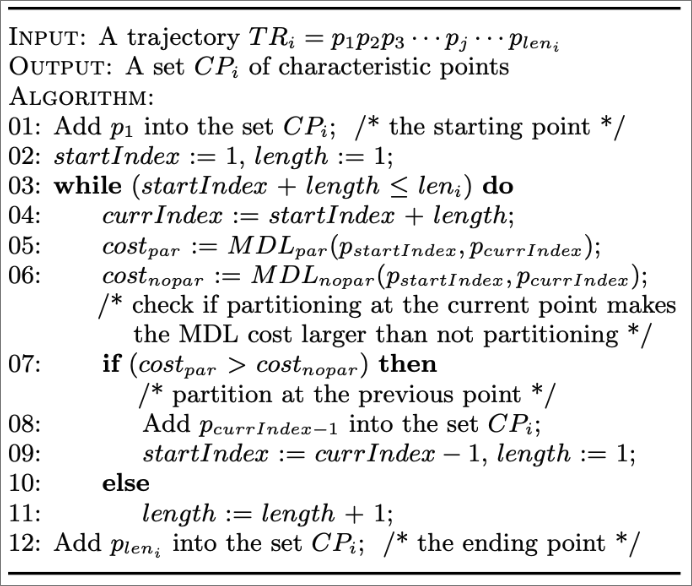

For one trajectory with $n$ points, the complexity is $O(n)$

The algorithm scans forward through the trajectory. 
When a partition is found, the current point may be checked again after changing `startIndex`,
This adds only a constant number of checks per point => the number of loop iterations is linear.

This analysis assumes that

$$
MDL_{par}(p_{start},p_{curr})
\quad
MDL_{nopar}(p_{start},p_{curr})
$$

are calculated in smart way, incrementally (in $O(1)$ per step). 
Otherwise algorithm recomputes each MDL cost by scanning all points between `startIndex` and `currIndex`, one comparison can take $O(n)$ time, rsulting in $1+2+\cdots+(n-1)=O(n^2)$



## b)   

Give an example where the approximate algorithm for trajectory partitioning fails
to ﬁnd the optimal partitioning

----

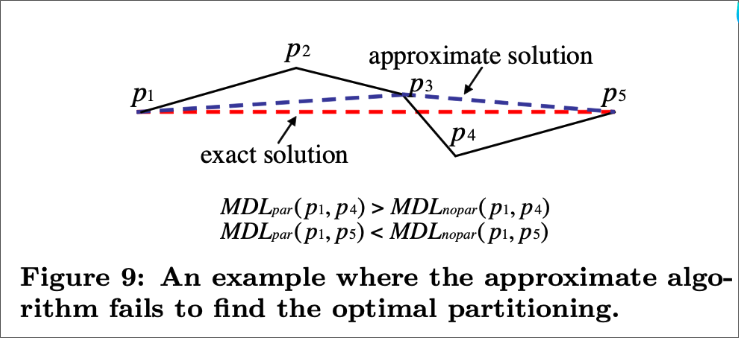

At $p_4$ the algorithm observes

$$
MDL_{par}(p_1,p_4) > MDL_{nopar}(p_1,p_4).
$$

It places a characteristic point at the previous point $p_3$. This produces

$$
\{p_1,p_3,p_5\}.
$$

However, after $p_5$ is included:

$$
MDL_{par}(p_1,p_5) < MDL_{nopar}(p_1,p_5).
$$

So the optimal solution is the single segment from $p_1$ to $p_5$, with characteristic points

$$
\{p_1,p_5\}.
$$

The approximate algorithm misses it because the choice of $p_3$ is irreversible


## c) 
Let’s consider hurricane trajectories. Intuitively, stronger hurricanes should have
higher weights when calculating the loss function Nε . How could you modify a density-based
clustering algorithm for line segmentation to take trajectory weights into account?

---

Assign each hurricane trajectory $T_i$ a weight $w_i$, for example according
to its maximum wind speed or hurricane category. For the
$\varepsilon$-neighborhood

$$
N_\varepsilon(L)
=
\{L_j:\operatorname{dist}(L,L_j)\leq\varepsilon\},
$$

replace the number of distinct trajectories by their total weight:

$$
W_\varepsilon(L)
=
\sum_{T_i\in N_\varepsilon(L)} w_i,
$$

$$
W_\varepsilon(L)\geq MinWeight.
$$



## d) 

Is the original distance function used in density-based clustering for line
segmentation a proper metric? Use the triangle inequality to provide a counterexample if it is
not

---

No. Distance is defined as

$$
\operatorname{dist}(L_i,L_j)
=
w_\perp d_\perp(L_i,L_j)
+w_\parallel d_\parallel(L_i,L_j)
+w_\theta d_\theta(L_i,L_j).
$$

Consider three collinear segments with the same orientation:

$$
A=[(0,0),(4,0)],\qquad
B=[(0,0),(1,0)],\qquad
C=[(1,0),(3,0)].
$$

Their perpendicular and angular distances are zero. Using the lecture's
parallel-distance definition, which takes the minimum endpoint-to-projection
distance, we obtain

$$
\operatorname{dist}(A,B)=0,\qquad
\operatorname{dist}(B,C)=0,\qquad
\operatorname{dist}(A,C)=1.
$$

The triangle inequality would require

$$
\operatorname{dist}(A,C)
\leq
\operatorname{dist}(A,B)+\operatorname{dist}(B,C),
$$

but this gives

$$
1\leq 0+0,
$$

which is false. Therefore the distance is not a proper metric. 
